In [1]:
# For one equilibrium
# Alter the specified neumann boundary condition at x_inner
# Alter the specified dirichlet boundary condition at x = 0 for ne

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sys
from pathlib import Path
from scipy.interpolate import interp1d
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.solver_nondim import saarelma_connor_nondim
from src.solver import saarelma_connor

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Equilibrium to scan
equil_num = 100
GEQDSK_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks")
PFILE_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles")
from collections import defaultdict


def initialize_inputs(equil_num, geqdsk_dir=GEQDSK_DIR, pfile_dir=PFILE_DIR):
    """Select equil_num g/p file pairs from the CAKE input directories.

    Files are named g{shot}.{time} and p{shot}.{time}. Selection prioritizes
    one equilibrium per shot number before adding additional times from shots
    that already have a selected equilibrium.
    """
    geqdsk_dir = Path(geqdsk_dir)
    pfile_dir = Path(pfile_dir)

    g_by_suffix = {
        f.name[1:]: f for f in geqdsk_dir.glob("g*") if f.is_file()
    }
    p_by_suffix = {
        f.name[1:]: f for f in pfile_dir.glob("p*") if f.is_file()
    }
    shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

    by_shot = defaultdict(list)
    for suffix in shared_suffixes:
        shot, time = suffix.split(".", 1)
        by_shot[shot].append((time, suffix))
    for shot in by_shot:
        by_shot[shot].sort()

    shots = sorted(by_shot)
    selected = []
    time_idx = 0
    while len(selected) < equil_num:
        added_this_round = False
        for shot in shots:
            if len(selected) >= equil_num:
                break
            entries = by_shot[shot]
            if time_idx < len(entries):
                suffix = entries[time_idx][1]
                selected.append(
                    (str(g_by_suffix[suffix]), str(p_by_suffix[suffix]))
                )
                added_this_round = True
        if not added_this_round:
            break
        time_idx += 1

    if len(selected) < equil_num:
        raise ValueError(
            f"Requested {equil_num} equilibria but only found {len(selected)} "
            f"matching g/p pairs in {geqdsk_dir} and {pfile_dir}"
        )

    print(f"Selected {len(selected)} g/p file pairs:")
    for mhd_fp, kprof_fp in selected:
        print(f"  g: {mhd_fp}\n  p: {kprof_fp}")
    return selected


mhd_fp, kprof_fp = initialize_inputs(equil_num)[20]

Selected 100 g/p file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153032.04475
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153032.04475
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153100.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153100.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153140.04750
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153140.04750
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153153.03800
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153153.03800
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g15

In [3]:
eq_tag = Path(mhd_fp).name[1:]  # e.g. "150840.03000"
scan_success_dir = Path("success")
eq_dir = scan_success_dir / eq_tag
eq_dir.mkdir(parents=True, exist_ok=True)

success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

eq_success_fp = eq_dir / success_fp
eq_failure_fp = eq_dir / failure_fp
eq_error_fp = eq_dir / error_messages_fp

# Clear outputs from any previous scan for this equilibrium.
for old in eq_dir.glob('ne_*.npy'):
    old.unlink()
for fp in (eq_success_fp, eq_failure_fp, eq_error_fp):
    fp.unlink(missing_ok=True)
with open(eq_success_fp, "w") as f:
    f.write("nex0, dnedx_psiN085, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, L2_error\n")
with open(eq_failure_fp, "w") as f:
    f.write("nex0, dnedx_psiN085, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner\n")
with open(eq_error_fp, "w") as f:
    f.write("nex0, dnedx_psiN085, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner, message\n")

In [4]:
# First calculate ne and dne/dx at x_inner and x = 0 from the p-file
def read_pfile_ne_at_psi(kprof_fp, psi_n,dnedx=False):
    psi_arr, ne_arr = [], []
    dne_dx_arr = []
    in_ne_block = False
    with open(kprof_fp) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    psi_arr = np.asarray(psi_arr)
    ne_arr = np.asarray(ne_arr) * 1e20
    if dnedx:
        dne_dx_arr = np.gradient(ne_arr, psi_arr)
        return float(interp1d(
            psi_arr, dne_dx_arr, kind="linear",
            bounds_error=False, fill_value="extrapolate",
        )(psi_n))
    else:
        return float(interp1d(
            psi_arr, ne_arr, kind="linear",
            bounds_error=False, fill_value="extrapolate",
        )(psi_n))

In [5]:
# First calculate ne and dne/dx at x_inner and x = 0 from the p-file
ne_inner_pfile = read_pfile_ne_at_psi(kprof_fp, 0.85)
dne_dx_inner_pfile = read_pfile_ne_at_psi(kprof_fp, 0.85, dnedx=True)
ne_x0_pfile = read_pfile_ne_at_psi(kprof_fp, 1.0)

print('ne_inner_pfile', ne_inner_pfile)
print('dne_dx_inner_pfile', dne_dx_inner_pfile)
print('ne_x0_pfile', ne_x0_pfile)

pert = 0.5
ne_inner_pfile_pert = np.linspace(ne_inner_pfile - pert*ne_inner_pfile, ne_inner_pfile + pert*ne_inner_pfile, 10)
dne_dx_inner_pfile_pert = np.linspace(dne_dx_inner_pfile - pert*dne_dx_inner_pfile, dne_dx_inner_pfile + pert*dne_dx_inner_pfile, 10)
ne_x0_pfile_pert = np.linspace(ne_x0_pfile - pert*ne_x0_pfile, ne_x0_pfile + pert*ne_x0_pfile, 10)

ne_inner_pfile 4.23506e+19
dne_dx_inner_pfile -3.813999999999961e+19
ne_x0_pfile 1.28918e+19


In [6]:
# Build base solver

# Solver parameters
SOLVE_KW = dict(
    x_res=40,
    fe_degree=2,
    initial_guess="tanh",
    ne_inner_bc="neumann",   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    nCX_ic="solve",
    kbm_treatment="inline",
    kbm_gate_eps=0.1, # 1e-3 minimum
    bc_origin="user",
    verbose=False,
)

# Scan parameters
N=3
alpha_crits = np.logspace(-1, 1, N)
C_KBMs = np.logspace(-1, 1, N)
De_chie_etgs = np.logspace(-1, 1, N)
nFC_x0s = np.logspace(15, 17, N)
ncx_x0_ratios = np.logspace(0.1,1.25,N)
psi_val = 0.85 # this is for the scan, not the analysis

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox


base_model = saarelma_connor_nondim(
    P_tot_e      = P_tot_e,
    alpha_crit   = round(float(alpha_crits[0]), 3),
    C_KBM        = round(float(C_KBMs[0]), 3),
    De_chie_etg  = round(float(De_chie_etgs[0]), 3),
    nFC_x0       = round(float(nFC_x0s[0]), 3),
    ncx_x0_ratio = round(float(ncx_x0_ratios[0]), 3),
    mhd_fp       = mhd_fp,
    kprof_fp     = kprof_fp,
    verbose      = False,
)

In [7]:
# Scan ne_x0
for ne_x0_pert in ne_x0_pfile_pert:
    for alpha_crit in alpha_crits:
        for C_KBM in C_KBMs:
            for De_chie_etg in De_chie_etgs:
                for nFC_x0 in nFC_x0s:
                    for ncx_x0_ratio in ncx_x0_ratios:
                        ac = round(float(alpha_crit), 3)
                        ck = round(float(C_KBM), 3)
                        de = round(float(De_chie_etg), 3)
                        nf = round(float(nFC_x0), 3)
                        nc = round(float(ncx_x0_ratio), 3)
                        try:
                                base_model.update_free_params(
                                        alpha_crit            = ac,
                                        C_KBM                 = ck,
                                        De_chie_etg           = de,
                                        nFC_x0                = nf,
                                        ncx_x0_ratio          = nc,
                                        psi_N_inner_boundary  = psi_val,
                                        ne_x0                 = ne_x0_pert,
                                )
                                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_coupled_nondim(ne_inner=ne_inner_pfile, dne_dx_inner=dne_dx_inner_pfile, **SOLVE_KW)
                                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                        except Exception as e:  # run fails
                            with open(eq_failure_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pert}, {dne_dx_inner_pfile}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
                            with open(eq_error_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pert}, {dne_dx_inner_pfile}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {e}\n")
                        else:  # run works
                            # Calculate L2 error between predicted and pfile
                            ne_pfile = interp1d(base_model.x_init, base_model.n_e_pres, kind='linear', bounds_error=False, fill_value='extrapolate')(x_sol)
                            L2_error = np.linalg.norm(ne_sol - ne_pfile) / np.linalg.norm(ne_pfile) # normalized L2 error
                            with open(eq_success_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pert}, {dne_dx_inner_pfile}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {L2_error}\n")
                            np.save(eq_dir / f"ne_nex0{ne_x0_pert}_dnedx{dne_dx_inner_pfile}_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}", sol, allow_pickle=True)

Ranked 228 parameter combinations by mean normalized L2 over ne_x0 BCs
Best combo: $\alpha_{crit}=10$, $C_{KBM}=10$, $D_e\chi_e^{ETG}=10$, $n_{FC}^{x_0}=1e+17$, $n_{CX}^{x_0}/n_{FC}^{x_0}=4.732$, mean L2=0.033
Worst combo: $\alpha_{crit}=10$, $C_{KBM}=0.1$, $D_e\chi_e^{ETG}=10$, $n_{FC}^{x_0}=1e+17$, $n_{CX}^{x_0}/n_{FC}^{x_0}=17.783$, mean L2=1.071


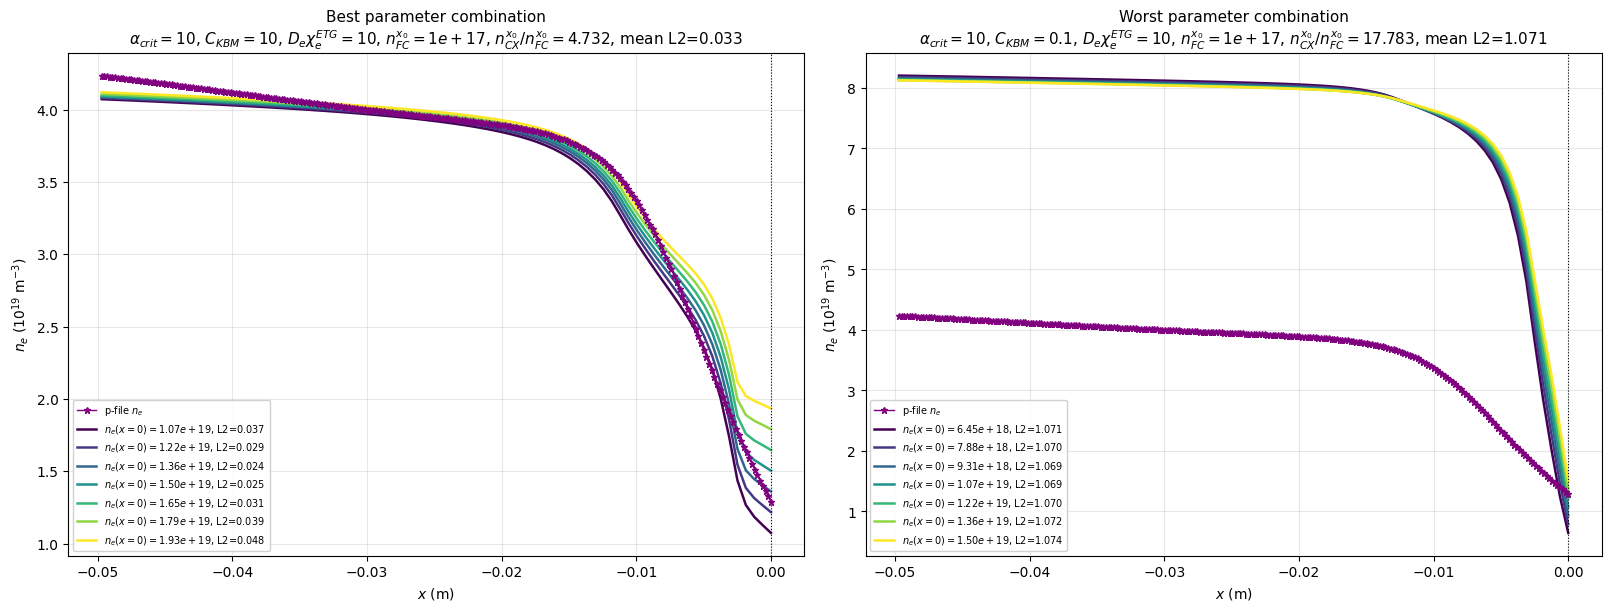

In [8]:
# Pick best / worst free-parameter combo (mean L2 over ne_x0 BC scan) and plot profiles
import csv
from collections import defaultdict

PARAM_KEYS = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")


def _param_combo_key(ac, ck, de, nf, nc):
    return (
        round(float(ac), 3),
        round(float(ck), 3),
        round(float(de), 3),
        round(float(nf), 3),
        round(float(nc), 3),
    )


def _npy_path(run):
    ac, ck, de, nf, nc = (
        run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
        run["nFC_x0"], run["ncx_x0_ratio"],
    )
    return eq_dir / (
        f"ne_nex0{run['ne_x0']}_dnedx{run['dnedx']}_"
        f"a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{run['psi_N_inner']:.4f}.npy"
    )


def load_ne_x0_scan_runs(success_path=eq_success_fp):
    runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            if len(row) < 10:
                continue
            _, ne_x0, dnedx, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:10]]
            run = dict(
                ne_x0=float(ne_x0),
                dnedx=float(dnedx),
                alpha_crit=round(float(ac), 3),
                C_KBM=round(float(ck), 3),
                De_chie_etg=round(float(de), 3),
                nFC_x0=round(float(nf), 3),
                ncx_x0_ratio=round(float(nc), 3),
                psi_N_inner=float(psi_b),
                L2_error=float(l2),
            )
            if np.isclose(run["dnedx"], dne_dx_inner_pfile, rtol=1e-3):
                runs.append(run)
    return runs


def mean_l2_by_combo(runs):
    groups = defaultdict(list)
    for run in runs:
        key = _param_combo_key(
            run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
            run["nFC_x0"], run["ncx_x0_ratio"],
        )
        groups[key].append(run["L2_error"])
    return {key: float(np.mean(vals)) for key, vals in groups.items()}


def profiles_for_combo(combo, runs):
    profiles = []
    for run in runs:
        if _param_combo_key(
            run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
            run["nFC_x0"], run["ncx_x0_ratio"],
        ) != combo:
            continue
        npy_path = _npy_path(run)
        if not npy_path.exists():
            continue
        sol = np.load(npy_path, allow_pickle=True).item()
        profiles.append(dict(
            ne_x0=run["ne_x0"],
            L2_error=run["L2_error"],
            x=np.asarray(sol["x"], dtype=float),
            ne=np.asarray(sol["y"], dtype=float),
        ))
    return sorted(profiles, key=lambda p: p["ne_x0"])


def combo_label(combo, mean_l2):
    ac, ck, de, nf, nc = combo
    return (
        rf"$\alpha_{{crit}}={ac:g}$, $C_{{KBM}}={ck:g}$, $D_e\chi_e^{{ETG}}={de:g}$, "
        rf"$n_{{FC}}^{{x_0}}={nf:.3g}$, $n_{{CX}}^{{x_0}}/n_{{FC}}^{{x_0}}={nc:g}$, "
        rf"mean L2={mean_l2:.3f}"
    )


def plot_combo_bc_profiles(ax, combo, mean_l2, profiles, title):
    if not profiles:
        ax.set_title(f"{title}\n(no saved profiles found)")
        return

    x_lo = min(p["x"].min() for p in profiles)
    x_hi = max(p["x"].max() for p in profiles)
    x_plot = np.linspace(x_lo, x_hi, 250)
    ne_pfile = interp1d(
        base_model.x_init, base_model.n_e_pres,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_plot)
    ax.plot(
        x_plot, ne_pfile / 1e19, "*-", color="purple", ms=5, lw=1.0,
        label="p-file $n_e$", zorder=10,
    )

    ne_x0_vals = np.array([p["ne_x0"] for p in profiles], dtype=float)
    ne_x0_norm = plt.Normalize(ne_x0_vals.min(), ne_x0_vals.max())
    cmap = plt.cm.viridis

    for prof in profiles:
        color = cmap(ne_x0_norm(prof["ne_x0"]))
        ax.plot(
            prof["x"], prof["ne"] / 1e19, color=color, lw=1.8,
            label=rf"$n_e(x=0)={prof['ne_x0']:.2e}$, L2={prof['L2_error']:.3f}",
        )

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)")
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)")
    ax.set_title(f"{title}\n{combo_label(combo, mean_l2)}", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best", framealpha=0.9)


scan_runs = load_ne_x0_scan_runs()
if not scan_runs:
    print(f"No successful runs found in {eq_success_fp}")
else:
    combo_scores = mean_l2_by_combo(scan_runs)
    best_combo = min(combo_scores, key=combo_scores.get)
    worst_combo = max(combo_scores, key=combo_scores.get)

    print(f"Ranked {len(combo_scores)} parameter combinations by mean normalized L2 over ne_x0 BCs")
    print("Best combo:", combo_label(best_combo, combo_scores[best_combo]))
    print("Worst combo:", combo_label(worst_combo, combo_scores[worst_combo]))

    best_profiles = profiles_for_combo(best_combo, scan_runs)
    worst_profiles = profiles_for_combo(worst_combo, scan_runs)

    fig, (ax_best, ax_worst) = plt.subplots(
        1, 2, figsize=(16, 6), constrained_layout=True,
    )
    plot_combo_bc_profiles(
        ax_best, best_combo, combo_scores[best_combo], best_profiles,
        "Best parameter combination",
    )
    plot_combo_bc_profiles(
        ax_worst, worst_combo, combo_scores[worst_combo], worst_profiles,
        "Worst parameter combination",
    )
    plt.show()

In [11]:
# Scan dne_dx_x_inner
for dne_dx_inner_pert in dne_dx_inner_pfile_pert:
    for alpha_crit in alpha_crits:
        for C_KBM in C_KBMs:
            for De_chie_etg in De_chie_etgs:
                for nFC_x0 in nFC_x0s:
                    for ncx_x0_ratio in ncx_x0_ratios:
                        ac = round(float(alpha_crit), 3)
                        ck = round(float(C_KBM), 3)
                        de = round(float(De_chie_etg), 3)
                        nf = round(float(nFC_x0), 3)
                        nc = round(float(ncx_x0_ratio), 3)
                        try:
                                base_model.update_free_params(
                                        alpha_crit            = ac,
                                        C_KBM                 = ck,
                                        De_chie_etg           = de,
                                        nFC_x0                = nf,
                                        ncx_x0_ratio          = nc,
                                        psi_N_inner_boundary  = psi_val,
                                        ne_x0                 = ne_x0_pfile,
                                )
                                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_coupled_nondim(ne_inner=ne_inner_pfile, dne_dx_inner=dne_dx_inner_pert, **SOLVE_KW)
                                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                        except Exception as e:  # run fails
                            with open(eq_failure_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pfile}, {dne_dx_inner_pert}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}\n")
                            with open(eq_error_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pfile}, {dne_dx_inner_pert}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {e}\n")
                        else:  # run works
                            # Calculate L2 error between predicted and pfile
                            ne_pfile = interp1d(base_model.x_init, base_model.n_e_pres, kind='linear', bounds_error=False, fill_value='extrapolate')(x_sol)
                            L2_error = np.linalg.norm(ne_sol - ne_pfile) / np.linalg.norm(ne_pfile) # normalized L2 error
                            with open(eq_success_fp, 'a') as f:
                                f.write(f"{eq_tag}, {ne_x0_pfile}, {dne_dx_inner_pert}, {ac}, {ck}, {de}, {nf}, {nc}, {psi_val:.4f}, {L2_error}\n")
                            np.save(eq_dir / f"ne_nex0{ne_x0_pfile}_dnedx{dne_dx_inner_pert}_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}", sol, allow_pickle=True)

Ranked 229 parameter combinations by mean normalized L2 over dne/dx inner BCs
Best combo: $\alpha_{crit}=10$, $C_{KBM}=10$, $D_e\chi_e^{ETG}=10$, $n_{FC}^{x_0}=1e+17$, $n_{CX}^{x_0}/n_{FC}^{x_0}=4.732$, mean L2=0.039
Worst combo: $\alpha_{crit}=10$, $C_{KBM}=0.1$, $D_e\chi_e^{ETG}=10$, $n_{FC}^{x_0}=1e+17$, $n_{CX}^{x_0}/n_{FC}^{x_0}=17.783$, mean L2=1.071


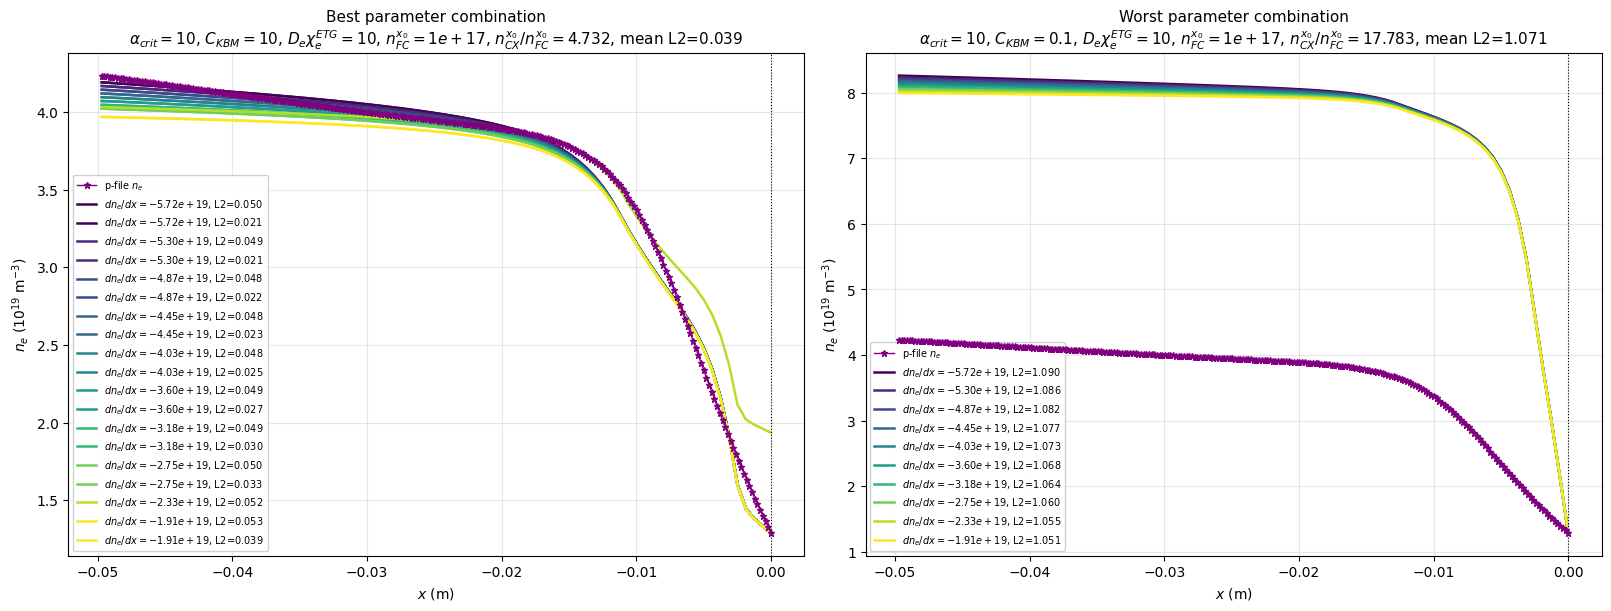

In [12]:
# Pick best / worst free-parameter combo (mean L2 over dne_dx inner BC scan) and plot profiles
import csv
from collections import defaultdict

PARAM_KEYS = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")


def _param_combo_key(ac, ck, de, nf, nc):
    return (
        round(float(ac), 3),
        round(float(ck), 3),
        round(float(de), 3),
        round(float(nf), 3),
        round(float(nc), 3),
    )


def _npy_path(run):
    ac, ck, de, nf, nc = (
        run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
        run["nFC_x0"], run["ncx_x0_ratio"],
    )
    return eq_dir / (
        f"ne_nex0{run['ne_x0']}_dnedx{run['dnedx']}_"
        f"a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{run['psi_N_inner']:.4f}.npy"
    )


def load_dnedx_scan_runs(success_path=eq_success_fp):
    runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            if len(row) < 10:
                continue
            _, ne_x0, dnedx, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:10]]
            run = dict(
                ne_x0=float(ne_x0),
                dnedx=float(dnedx),
                alpha_crit=round(float(ac), 3),
                C_KBM=round(float(ck), 3),
                De_chie_etg=round(float(de), 3),
                nFC_x0=round(float(nf), 3),
                ncx_x0_ratio=round(float(nc), 3),
                psi_N_inner=float(psi_b),
                L2_error=float(l2),
            )
            if np.isclose(run["ne_x0"], ne_x0_pfile, rtol=1e-3):
                runs.append(run)
    return runs


def mean_l2_by_combo(runs):
    groups = defaultdict(list)
    for run in runs:
        key = _param_combo_key(
            run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
            run["nFC_x0"], run["ncx_x0_ratio"],
        )
        groups[key].append(run["L2_error"])
    return {key: float(np.mean(vals)) for key, vals in groups.items()}


def profiles_for_combo(combo, runs):
    profiles = []
    for run in runs:
        if _param_combo_key(
            run["alpha_crit"], run["C_KBM"], run["De_chie_etg"],
            run["nFC_x0"], run["ncx_x0_ratio"],
        ) != combo:
            continue
        npy_path = _npy_path(run)
        if not npy_path.exists():
            continue
        sol = np.load(npy_path, allow_pickle=True).item()
        profiles.append(dict(
            dnedx=run["dnedx"],
            L2_error=run["L2_error"],
            x=np.asarray(sol["x"], dtype=float),
            ne=np.asarray(sol["y"], dtype=float),
        ))
    return sorted(profiles, key=lambda p: p["dnedx"])


def combo_label(combo, mean_l2):
    ac, ck, de, nf, nc = combo
    return (
        rf"$\alpha_{{crit}}={ac:g}$, $C_{{KBM}}={ck:g}$, $D_e\chi_e^{{ETG}}={de:g}$, "
        rf"$n_{{FC}}^{{x_0}}={nf:.3g}$, $n_{{CX}}^{{x_0}}/n_{{FC}}^{{x_0}}={nc:g}$, "
        rf"mean L2={mean_l2:.3f}"
    )


def plot_combo_bc_profiles(ax, combo, mean_l2, profiles, title):
    if not profiles:
        ax.set_title(f"{title}\n(no saved profiles found)")
        return

    x_lo = min(p["x"].min() for p in profiles)
    x_hi = max(p["x"].max() for p in profiles)
    x_plot = np.linspace(x_lo, x_hi, 250)
    ne_pfile = interp1d(
        base_model.x_init, base_model.n_e_pres,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_plot)
    ax.plot(
        x_plot, ne_pfile / 1e19, "*-", color="purple", ms=5, lw=1.0,
        label="p-file $n_e$", zorder=10,
    )

    dnedx_vals = np.array([p["dnedx"] for p in profiles], dtype=float)
    dnedx_norm = plt.Normalize(dnedx_vals.min(), dnedx_vals.max())
    cmap = plt.cm.viridis

    for prof in profiles:
        color = cmap(dnedx_norm(prof["dnedx"]))
        ax.plot(
            prof["x"], prof["ne"] / 1e19, color=color, lw=1.8,
            label=rf"$dn_e/dx={prof['dnedx']:.2e}$, L2={prof['L2_error']:.3f}",
        )

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)")
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)")
    ax.set_title(f"{title}\n{combo_label(combo, mean_l2)}", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best", framealpha=0.9)


scan_runs = load_dnedx_scan_runs()
if not scan_runs:
    print(f"No successful dne/dx-inner BC runs found in {eq_success_fp}")
    print(f"(expected ne_x0 fixed at {ne_x0_pfile:.3e})")
else:
    combo_scores = mean_l2_by_combo(scan_runs)
    best_combo = min(combo_scores, key=combo_scores.get)
    worst_combo = max(combo_scores, key=combo_scores.get)

    print(f"Ranked {len(combo_scores)} parameter combinations by mean normalized L2 over dne/dx inner BCs")
    print("Best combo:", combo_label(best_combo, combo_scores[best_combo]))
    print("Worst combo:", combo_label(worst_combo, combo_scores[worst_combo]))

    best_profiles = profiles_for_combo(best_combo, scan_runs)
    worst_profiles = profiles_for_combo(worst_combo, scan_runs)

    fig, (ax_best, ax_worst) = plt.subplots(
        1, 2, figsize=(16, 6), constrained_layout=True,
    )
    plot_combo_bc_profiles(
        ax_best, best_combo, combo_scores[best_combo], best_profiles,
        "Best parameter combination",
    )
    plot_combo_bc_profiles(
        ax_worst, worst_combo, combo_scores[worst_combo], worst_profiles,
        "Worst parameter combination",
    )
    plt.show()